# 02 Regression Analysis
This notebook loads the cleaned analysis dataset and runs logistic regression models 
predicting phone ownership and internet use from wealth, education, urban/rural residence, 
and maternal age. Results are presented as odds ratios and predicted probabilities.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf

analysis_data = pd.read_csv('../analysis_data.csv')

analysis_data.head()

,phone_owns,internet_use,wealth_quintile,education,urban_rural,maternal_age
0,1,0,4,No education,Urban,34
1,1,1,5,Secondary,Urban,38
2,1,1,5,Primary,Urban,33
3,1,1,5,Secondary,Urban,39
4,1,1,4,Primary,Urban,30


### Logistic Regression: Internet Use
I modelled internet use as a function of wealth, education, urban/rural residence, 
and maternal age.

In [7]:
model_internet = smf.logit(
    'internet_use ~ C(wealth_quintile) + C(education) + C(urban_rural) + maternal_age',
    data=analysis_data
).fit()

print(model_internet.summary())

Optimization terminated successfully.
         Current function value: 0.423535
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           internet_use   No. Observations:                32156
Model:                          Logit   Df Residuals:                    32146
Method:                           MLE   Df Model:                            9
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.3567
Time:                        15:12:36   Log-Likelihood:                -13619.
converged:                       True   LL-Null:                       -21172.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.1149      0.087      1.316      0.188

### Logistic Regression: Phone Ownership

In [9]:
model_phone = smf.logit(
    'phone_owns ~ C(wealth_quintile) + C(education) + C(urban_rural) + maternal_age',
    data=analysis_data
).fit()

print(model_phone.summary())

Optimization terminated successfully.
         Current function value: 0.410832
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             phone_owns   No. Observations:                32156
Model:                          Logit   Df Residuals:                    32146
Method:                           MLE   Df Model:                            9
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.2730
Time:                        15:12:37   Log-Likelihood:                -13211.
converged:                       True   LL-Null:                       -18172.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -0.4361      0.148     -2.946      0.003

### Odds Ratios
Regression results are presented as odds ratios for easier interpretation. The reference categories are wealth quintile 1, higher education, and rural residence. An odds ratio above 1 means more likely, below 1 means less likely.

In [11]:
# internet use odds ratios
internet_or = np.exp(model_internet.params)
internet_ci = np.exp(model_internet.conf_int())
internet_or_table = pd.concat([internet_or, internet_ci], axis=1)
internet_or_table.columns = ['Odds Ratio', 'Lower 95% CI', 'Upper 95% CI']
internet_or_table = internet_or_table.round(3)
print("Internet Use - Odds Ratios")
print(internet_or_table)

Internet Use - Odds Ratios
                              Odds Ratio  Lower 95% CI  Upper 95% CI
Intercept                          1.122         0.945         1.331
C(wealth_quintile)[T.2]            2.221         1.947         2.533
C(wealth_quintile)[T.3]            4.305         3.800         4.878
C(wealth_quintile)[T.4]            8.673         7.617         9.875
C(wealth_quintile)[T.5]           19.894        17.176        23.042
C(education)[T.No education]       0.019         0.016         0.023
C(education)[T.Primary]            0.044         0.039         0.049
C(education)[T.Secondary]          0.132         0.118         0.147
C(urban_rural)[T.Urban]            1.103         1.022         1.190
maternal_age                       0.998         0.995         1.002


In [12]:
# phone ownership odds ratios
phone_or = np.exp(model_phone.params)
phone_ci = np.exp(model_phone.conf_int())
phone_or_table = pd.concat([phone_or, phone_ci], axis=1)
phone_or_table.columns = ['Odds Ratio', 'Lower 95% CI', 'Upper 95% CI']
phone_or_table = phone_or_table.round(3)
print("Phone Ownership - Odds Ratios")
print(phone_or_table)

Phone Ownership - Odds Ratios
                              Odds Ratio  Lower 95% CI  Upper 95% CI
Intercept                          0.647         0.484         0.864
C(wealth_quintile)[T.2]            1.617         1.480         1.766
C(wealth_quintile)[T.3]            2.356         2.147         2.585
C(wealth_quintile)[T.4]            3.619         3.240         4.041
C(wealth_quintile)[T.5]            5.546         4.792         6.419
C(education)[T.No education]       0.043         0.032         0.057
C(education)[T.Primary]            0.044         0.033         0.057
C(education)[T.Secondary]          0.078         0.060         0.101
C(urban_rural)[T.Urban]            1.161         1.067         1.262
maternal_age                       1.138         1.133         1.142


### Predicted Probabilities
Predicted probabilities are generated across wealth quintiles, holding education at primary and residence at rural. This represents a realistic profile for a typical Kenyan woman in this sample.

In [14]:
pred_data = pd.DataFrame({
    'wealth_quintile': [1, 2, 3, 4, 5],
    'education': ['Primary'] * 5,
    'urban_rural': ['Rural'] * 5,
    'maternal_age': [analysis_data['maternal_age'].mean()] * 5
})

pred_data['internet_pred'] = model_internet.predict(pred_data)
pred_data['phone_pred'] = model_phone.predict(pred_data)

print(pred_data[['wealth_quintile', 'internet_pred', 'phone_pred']].round(3))

   wealth_quintile  internet_pred  phone_pred
0                1          0.045       0.548
1                2          0.094       0.662
2                3          0.168       0.740
3                4          0.289       0.814
4                5          0.482       0.870


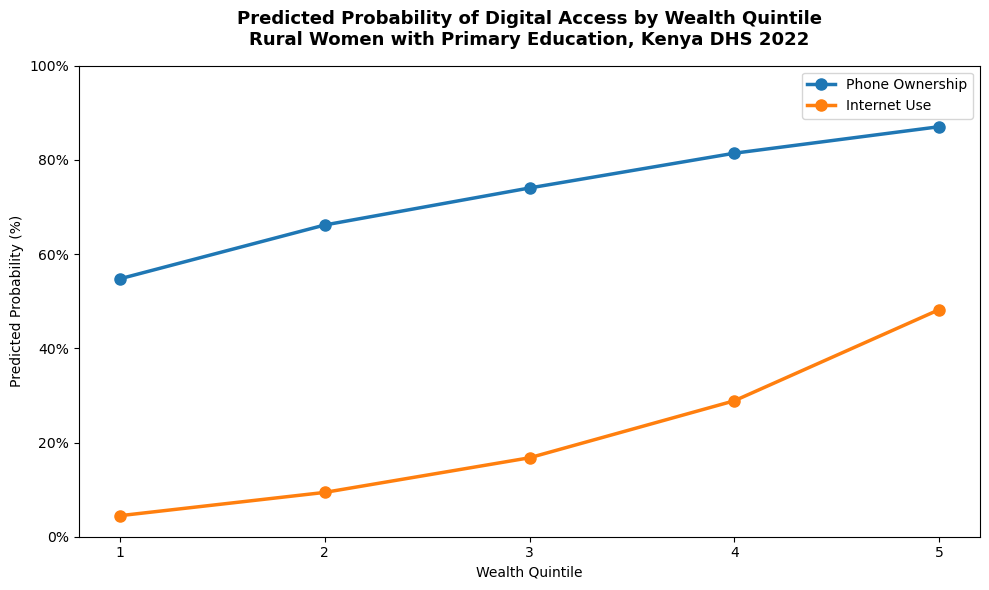

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot([1, 2, 3, 4, 5], pred_data['phone_pred'] * 100,
        marker='o', linewidth=2.5, markersize=8, label='Phone Ownership')
ax.plot([1, 2, 3, 4, 5], pred_data['internet_pred'] * 100,
        marker='o', linewidth=2.5, markersize=8, label='Internet Use')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel('Wealth Quintile')
ax.set_ylabel('Predicted Probability (%)')
ax.set_title('Predicted Probability of Digital Access by Wealth Quintile\nRural Women with Primary Education, Kenya DHS 2022',
             fontsize=13, fontweight='bold', pad=15)
ax.legend()

plt.tight_layout()
plt.savefig('../output/predicted_probs.png', dpi=300, bbox_inches='tight') 
plt.show()